# PFN + BNNPrior showcase (M2)

Trains a small PFN (`anytimeacquisition.models.pfn.PFN`) against the M1 `BNNPrior`, via the bounded `BarDistribution` NLL, then shows the prior's true function, the sampled train data, and the PFN's predictive density overlaid on the same plot — the diagnostic for "is the PFN's predictive distribution actually tracking the true function."

Background:
- `docs/log/2026-08-27-pfns4bo-bnn-prior-comparison.md` (+ addendum) — PFNs4BO's/ifBO's own PFN architecture and training procedure, and what we did/didn't carry over
- `docs/OPEN_QUESTIONS.md` #8 — bounded bar distribution on M1's ECDF-normalized output (this notebook), vs. PFNs4BO's unbounded/adaptive-borders approach (not built)
- `docs/milestones/M2.md` — checklist this notebook is showcasing
- `src/anytimeacquisition/models/pfn.py`, `src/anytimeacquisition/models/bar_distribution.py`, `src/anytimeacquisition/pipelines/train_pfn.py`

In [1]:
import torch

from anytimeacquisition.models.pfn import PFN
from anytimeacquisition.models.bar_distribution import BarDistribution, uniform_bin_borders
from anytimeacquisition.priors.bnn import BNNPrior
from anytimeacquisition.pipelines.train_pfn import train_pfn, plot_prior_data_and_pfn_1d

torch.manual_seed(0)
PRIOR_KWARGS = dict(ecdf_n_draws=50, ecdf_samples_per_draw=300, cache_dir=None)

/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Architecture sanity checks (M2 checklist)

Before training anything: verify the two invariances the whole PFN design depends on, numerically — not just asserted. Full versions of these live in `tests/test_pfn.py`.

In [2]:
USE_PRETRAINED = True

if USE_PRETRAINED:
    from anytimeacquisition.utils.paths import CHECKPOINT_DIR
    from anytimeacquisition.pipelines.train_pfn import load_pfn_checkpoint

    # A variable-x_dim checkpoint (experiment=pfn_variable_xdim_smoke, see
    # docs/log/2026-08-31-variable-xdim-training-stagnation.md) works fine
    # here even though it wasn't trained at a single fixed x_dim=1 -- the
    # PFN's own max_x_dim/n_features padding (models/pfn.py) means any
    # checkpoint built with max_x_dim >= 1 can be queried at exactly
    # x_dim=1, which is all this notebook ever does below. Point this at
    # wherever you copied your own trained .pt to if it's named
    # differently.
    checkpoint_path = CHECKPOINT_DIR / "pfn_variable_xdim_smoke.pt"
    model, bar_dist, ckpt = load_pfn_checkpoint(checkpoint_path)
    assert ckpt["config"]["max_x_dim"] >= 1, (
        f"{checkpoint_path.name} was built for max_x_dim={ckpt['config']['max_x_dim']}, "
        "but these panels need at least x_dim=1 -- see the module docstring above."
    )
    print(f"loaded PFN checkpoint: {checkpoint_path.name}, config={ckpt['config']}")
else:

    model = PFN(max_x_dim=1, d_model=48, n_heads=4, n_layers=3, d_ff=96, n_bins=64)

    x_train, y_train = torch.rand(2, 6, 1), torch.rand(2, 6)
    x_test = torch.rand(2, 4, 1)

    logits = model(x_train, y_train, x_test)
    perm = torch.randperm(6)
    logits_perm = model(x_train[:, perm], y_train[:, perm], x_test)
    print("permutation invariance, max abs diff (expect ~0):", (logits - logits_perm).abs().max().item())

    x_test_pert = x_test.clone()
    x_test_pert[:, 0, :] += 1.0
    logits_pert = model(x_train, y_train, x_test_pert)
    print("no test-test leakage, max diff at OTHER test points (expect ~0):", (logits[:, 1:, :] - logits_pert[:, 1:, :]).abs().max().item())

loaded PFN checkpoint: pfn_variable_xdim_smoke.pt, config={'max_x_dim': 4, 'd_model': 64, 'n_heads': 4, 'n_layers': 3, 'd_ff': 128, 'n_bins': 64}


## Train a small PFN

Only runs if `USE_PRETRAINED = False` above -- otherwise the loaded checkpoint's `model`/`bar_dist` from the previous cell would just get silently overwritten here, discarding whatever was actually loaded. `x_dim=1` so the predictive density can be visualized as a 2D heatmap below. A fresh `BNNPrior` instance is drawn every step (see `train_pfn.py`) — this is intentionally a small/fast run for a notebook, not the real M2 checkpoint (see `docs/milestones/M2.md` for what a serious run should look like; `pipelines/train_pfn.py`'s own `__main__` trains a slightly larger x_dim=2 smoke checkpoint).

In [3]:
if not USE_PRETRAINED:
    result = train_pfn(
        x_dim=1,
        d_model=48, n_heads=4, n_layers=3, d_ff=96, n_bins=64,
        batch_size=32, min_train=3, max_train=20, n_test=10,
        n_steps=300, log_every=50,
        prior_kwargs=PRIOR_KWARGS,
    )
    model, bar_dist = result["model"], result["bar_dist"]

## Prior + data + PFN predictive density, overlaid

Background: the true function on a dense grid, and the sampled train points. Heatmap: the PFN's predictive density (`softmax(logits) / bucket_width`) at every grid point, conditioned on that same train context — same idea as reading a classical GP posterior mean/CI band, but this is the PFN's full predictive distribution, not just a mean/variance summary.

A well-trained PFN should show density concentrating along the true curve, tighter near train points and looser in gaps between them.

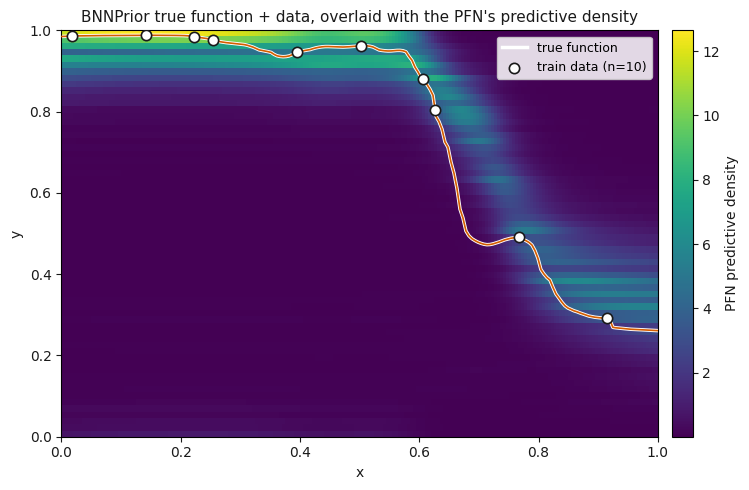

In [4]:
_ = plot_prior_data_and_pfn_1d(model, bar_dist, prior_kwargs=PRIOR_KWARGS, n_train=10, seed=11)

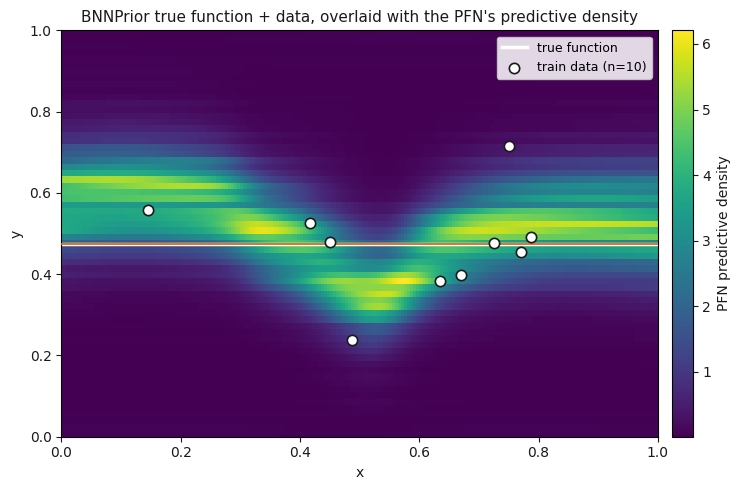

In [5]:
_ = plot_prior_data_and_pfn_1d(model, bar_dist, prior_kwargs=PRIOR_KWARGS, n_train=10, seed=27)

### Effect of context size

Same environment (fixed seed), more train points — the density should visibly sharpen around the true function as context grows, since that's the in-context learning signal the PFN is supposed to have picked up.

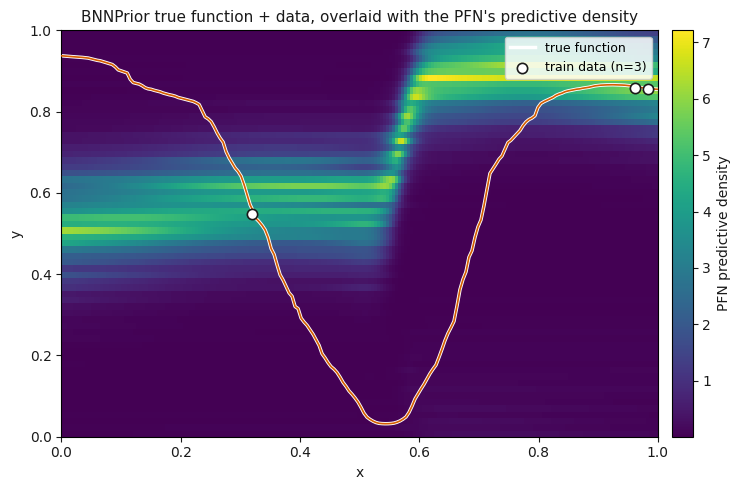

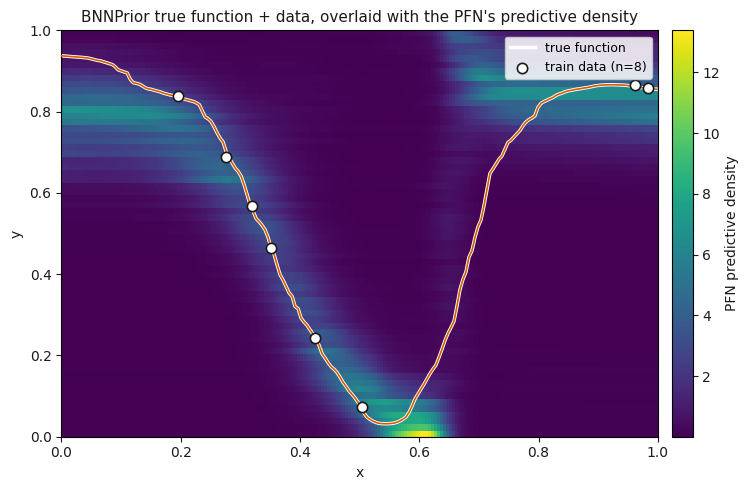

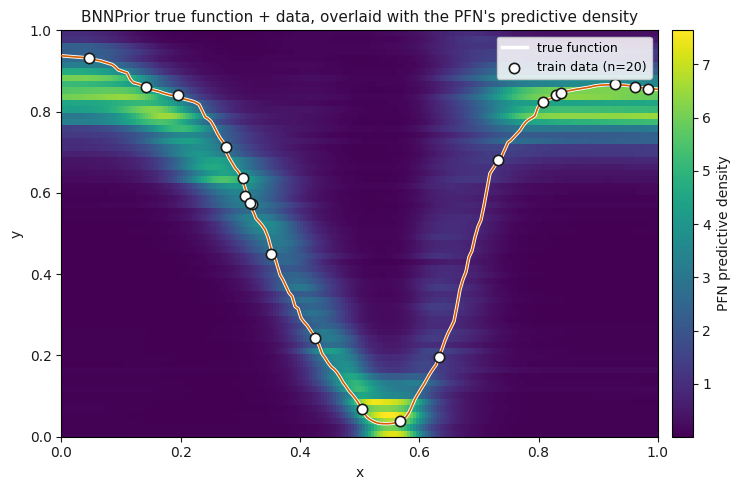

In [6]:
for n_train in (3, 8, 20):
    plot_prior_data_and_pfn_1d(model, bar_dist, prior_kwargs=PRIOR_KWARGS, n_train=n_train, seed=42)

## Predictive entropy across context size

The closed-form entropy M5's explore branch will search over — mean entropy over a fixed grid, as train context grows. Expect a generally decreasing trend (more context -> more certainty), though not necessarily monotonic at every single point (see `docs/log/2026-08-27-bnn-prior-flat-draws-crit-scaling.md`'s note on this being an open, dimensionality-sensitive finding even in the original prototype).

In [7]:
torch.manual_seed(42)
prior = BNNPrior(batch_size=1, x_dim=1, seed=42, **PRIOR_KWARGS)
x_grid = torch.linspace(0, 1, 200).view(1, -1, 1)

for n_train in (2, 5, 10, 20):
    x_tr, y_tr, _, _ = prior.sample_episode(n_train=n_train, n_test=0)
    with torch.no_grad():
        logits = model(x_tr, y_tr, x_grid)
        mean_entropy = bar_dist.entropy(logits).mean().item()
    print(f"n_train={n_train:3d}  mean predictive entropy over grid: {mean_entropy:.3f}")

n_train=  2  mean predictive entropy over grid: -1.025
n_train=  5  mean predictive entropy over grid: -1.215
n_train= 10  mean predictive entropy over grid: -0.917
n_train= 20  mean predictive entropy over grid: -0.892
